# LKH-3 — Lin-Kernighan-Helsgott v3

## Description

LKH-3 est l'heuristique **Lin-Kernighan-Helsgott v3** (Helsgott, 2000+), état de l'art classique pour le TSP.

| Composant | Description |
|-----------|-------------|
| **Plus proche voisin** | Construction initiale gloutonne |
| **Listes de candidats** | k plus proches voisins par ville — restreint les échanges |
| **2-opt** | Supprime 2 arêtes et reconnecte mieux |
| **Or-opt** | Déplace des segments de 1, 2 ou 3 villes |
| **Double-bridge** | Perturbation 4-opt impossible à défaire par recherche séquentielle |
| **ILK** | Iterated Lin-Kernighan : perturbation → optimisation locale |

## Formules clés

**Gain 2-opt** entre les arêtes $(t_1,t_2)$ et $(t_3,t_4)$ :

$$G = d(t_1,t_2) + d(t_3,t_4) - d(t_1,t_3) - d(t_2,t_4)$$

Avec les candidats triés par distance croissante, on stoppe dès que $d(t_1,t_3) \geq d(t_1,t_2)$.

**Gain Or-opt** (segment $[s_0,\ldots,s_{l-1}]$ entre $a$–$b$, déplacé vers $u$–$v$) :

$$G = d(a,s_0) + d(s_{l-1},b) + d(u,v) - d(a,b) - d(u,s_0) - d(s_{l-1},v)$$

**Double-bridge** : $A + B + C + D \rightarrow A + C + B + D$


In [2]:
import numpy as np
import time
from pathlib import Path
from typing import List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt


## Implémentation


In [3]:
class LKH3Solver:
    """
    Iterated Lin-Kernighan heuristic (LKH-3 style).

    Pipeline
    --------
    1. Nearest-Neighbour construction
    2. 2-opt  (candidate-list restricted)
    3. Or-opt (segments of 1, 2, 3 cities — forward + reversed)
    4. Double-bridge perturbation  ->  goto 2
    """

    def __init__(self, coords, k: int = 10, seed: int = 42):
        self.coords = np.asarray(coords, dtype=np.float64)
        self.n = len(self.coords)
        self.k = min(k, max(1, self.n - 1))
        self.rng = np.random.default_rng(seed)

        self.dist       = self._compute_distances()
        self.candidates = self._build_candidates()   # (n, k) sorted ascending

        self.converged:     bool      = False
        self.early_stopped: bool      = False
        self.best_tour:     List[int] = []
        self.best_length:   float     = float("inf")
        self.elapsed:       float     = 0.0

    # ------------------------------------------------------------------
    # Setup
    # ------------------------------------------------------------------

    def _compute_distances(self) -> np.ndarray:
        diff = self.coords[:, None, :] - self.coords[None, :, :]
        return np.sqrt((diff ** 2).sum(axis=-1))

    def _build_candidates(self) -> np.ndarray:
        """k nearest neighbours for each city (self excluded), sorted by distance."""
        return np.argsort(self.dist, axis=1)[:, 1 : self.k + 1]

    # ------------------------------------------------------------------
    # Tour utilities
    # ------------------------------------------------------------------

    def _tour_length(self, tour: List[int]) -> float:
        t = np.asarray(tour)
        return float(self.dist[t, np.roll(t, -1)].sum())

    def _nn_tour(self, start: Optional[int] = None) -> List[int]:
        """Greedy nearest-neighbour construction."""
        n = self.n
        if start is None:
            start = int(self.rng.integers(0, n))
        visited = np.zeros(n, dtype=bool)
        tour = [start]
        visited[start] = True
        for _ in range(n - 1):
            d = self.dist[tour[-1]].copy()
            d[visited] = np.inf
            nxt = int(np.argmin(d))
            tour.append(nxt)
            visited[nxt] = True
        return tour

    # ------------------------------------------------------------------
    # 2-opt (candidate-list restricted)
    # ------------------------------------------------------------------

    def _two_opt_improve(self, tour: List[int]) -> List[int]:
        """
        Repeatedly apply improving 2-opt moves until convergence.

        For each edge (t1,t2) and each candidate t3 of t1 (sorted by distance):
            gain = d(t1,t2) + d(t3,t4) - d(t1,t3) - d(t2,t4)
        Early exit when d(t1,t3) >= d(t1,t2) — no further gain possible.
        """
        n = self.n
        t = list(tour)
        city_pos = np.empty(n, dtype=np.int32)
        for i, c in enumerate(t):
            city_pos[c] = i

        improved = True
        while improved:
            improved = False
            for i in range(n):
                t1  = t[i]
                t2  = t[(i + 1) % n]
                d12 = self.dist[t1, t2]

                for t3 in self.candidates[t1]:
                    if self.dist[t1, t3] >= d12:
                        break  # no improving candidate beyond this point
                    j  = int(city_pos[t3])
                    t4 = t[(j + 1) % n]
                    if t3 == t2 or t4 == t1:
                        continue
                    gain = d12 + self.dist[t3, t4] - self.dist[t1, t3] - self.dist[t2, t4]
                    if gain > 1e-10:
                        # Reverse the segment between the two broken edges
                        if i < j:
                            t[i + 1 : j + 1] = t[i + 1 : j + 1][::-1]
                            for k in range(i + 1, j + 1):
                                city_pos[t[k]] = k
                        else:
                            t[j + 1 : i + 1] = t[j + 1 : i + 1][::-1]
                            for k in range(j + 1, i + 1):
                                city_pos[t[k]] = k
                        improved = True
                        break
        return t

    # ------------------------------------------------------------------
    # Or-opt (segments of length 1, 2, 3)
    # ------------------------------------------------------------------

    def _or_opt_improve(self, tour: List[int]) -> List[int]:
        """
        Or-opt: try relocating chains of 1, 2, 3 consecutive cities.
        Candidate insertion points come from candidates[seg[0]].
        Both forward and reversed insertions are evaluated.

        Gain formula:
            G = d(a,s0) + d(sl,b) + d(u,v) - d(a,b) - d(u,s0) - d(sl,v)
        where [s0..sl] is the segment, a/b its neighbours, u-v the target edge.
        """
        n = self.n
        t = list(tour)

        for seg_len in (1, 2, 3):
            if n <= seg_len + 1:
                continue

            city_pos = {c: i for i, c in enumerate(t)}
            improved = True

            while improved:
                improved = False
                for i in range(n):
                    seg     = [t[(i + s) % n] for s in range(seg_len)]
                    a       = t[(i - 1) % n]
                    b       = t[(i + seg_len) % n]
                    seg_set = set(seg)
                    if a == b:
                        continue

                    gain_rem = (self.dist[a, seg[0]] + self.dist[seg[-1], b]
                                - self.dist[a, b])

                    best_gain = 1e-10
                    best_u    = None
                    best_rev  = False

                    for u in self.candidates[seg[0]]:
                        if u in seg_set or u == a:
                            continue
                        v   = t[(city_pos[u] + 1) % n]
                        if v in seg_set:
                            continue
                        duv = self.dist[u, v]

                        # Forward: u -> seg[0] -> ... -> seg[-1] -> v
                        g = gain_rem + duv - self.dist[u, seg[0]] - self.dist[seg[-1], v]
                        if g > best_gain:
                            best_gain, best_u, best_rev = g, u, False

                        # Reversed: u -> seg[-1] -> ... -> seg[0] -> v
                        g_r = gain_rem + duv - self.dist[u, seg[-1]] - self.dist[seg[0], v]
                        if g_r > best_gain:
                            best_gain, best_u, best_rev = g_r, u, True

                    if best_u is not None:
                        seg_out   = seg[::-1] if best_rev else seg
                        remaining = [c for c in t if c not in seg_set]
                        ins = remaining.index(best_u)
                        t   = remaining[: ins + 1] + seg_out + remaining[ins + 1 :]
                        city_pos = {c: idx for idx, c in enumerate(t)}
                        improved = True
                        break
        return t

    # ------------------------------------------------------------------
    # Double-bridge perturbation
    # ------------------------------------------------------------------

    def _double_bridge(self, tour: List[int]) -> List[int]:
        """
        4-opt double-bridge: split tour into 4 segments and reconnect
        as  A + C + B + D  instead of  A + B + C + D.
        Cannot be reversed by sequential 2-opt or 3-opt.
        """
        n = self.n
        if n < 8:
            return tour[:]
        a, b, c, d = sorted(self.rng.choice(n, size=4, replace=False).tolist())
        return (tour[: a + 1]
                + tour[c + 1 : d + 1]
                + tour[b + 1 : c + 1]
                + tour[a + 1 : b + 1]
                + tour[d + 1 :])

    # ------------------------------------------------------------------
    # Main solve — Iterated Lin-Kernighan
    # ------------------------------------------------------------------

    def solve(
        self,
        n_restarts: int = 20,
        time_limit: Optional[float] = None,
    ) -> Tuple[List[int], float]:
        """
        Iterated Lin-Kernighan loop.

        Parameters
        ----------
        n_restarts  : number of double-bridge perturbation attempts
        time_limit  : wall-clock budget in seconds (None = unlimited)

        Returns
        -------
        (best_tour, best_length)
        """
        t0 = time.perf_counter()
        self.converged     = False
        self.early_stopped = False

        if self.n == 1:
            self.best_tour, self.best_length = [0], 0.0
            self.elapsed = 0.0
            self.converged = True
            return self.best_tour, self.best_length

        best     = self._nn_tour()
        best     = self._two_opt_improve(best)
        best     = self._or_opt_improve(best)
        best_len = self._tour_length(best)
        no_impr  = 0

        for _ in range(n_restarts):
            if time_limit and (time.perf_counter() - t0) > time_limit:
                self.early_stopped = True
                break
            t      = self._double_bridge(best)
            t      = self._two_opt_improve(t)
            t      = self._or_opt_improve(t)
            length = self._tour_length(t)
            if length < best_len - 1e-10:
                best, best_len, no_impr = t, length, 0
            else:
                no_impr += 1

        if no_impr == n_restarts:
            self.converged = True

        self.best_tour   = best
        self.best_length = best_len
        self.elapsed     = time.perf_counter() - t0
        return best, best_len


## Oracle exact — Held-Karp (n ≤ 12)


In [4]:
def held_karp(dist: np.ndarray) -> Tuple[List[int], float]:
    """
    Exact TSP via Held-Karp DP.  O(n^2 * 2^n).
    Only feasible for n <= 15.
    """
    n    = len(dist)
    assert n <= 15, f"n={n} is too large for Held-Karp"
    INF  = float("inf")
    size = 1 << n
    dp     = [[INF] * n for _ in range(size)]
    parent = [[-1]  * n for _ in range(size)]
    dp[1][0] = 0.0

    for mask in range(1, size):
        if not (mask & 1):
            continue
        for u in range(n):
            if not (mask & (1 << u)) or dp[mask][u] == INF:
                continue
            for v in range(n):
                if mask & (1 << v):
                    continue
                nm = mask | (1 << v)
                nc = dp[mask][u] + dist[u, v]
                if nc < dp[nm][v]:
                    dp[nm][v] = nc
                    parent[nm][v] = u

    full = size - 1
    best_cost, last = INF, -1
    for u in range(1, n):
        c = dp[full][u] + dist[u, 0]
        if c < best_cost:
            best_cost, last = c, u

    tour, mask, u = [], full, last
    while u != -1:
        tour.append(u)
        prev = parent[mask][u]
        mask ^= (1 << u)
        u = prev
    tour.reverse()
    return tour, best_cost


## Benchmark


In [5]:
EXACT_THRESHOLD = 12   # use Held-Karp exact optimal for n <= this

def _time_limit(n: int) -> Optional[float]:
    if n <= 100:    return None
    if n <= 1_000:  return 30.0
    if n <= 10_000: return 60.0
    return 120.0

def _n_restarts(n: int) -> int:
    if n <= 100:    return 50
    if n <= 1_000:  return 20
    if n <= 10_000: return 5
    return 2


def benchmark_size(n: int, n_runs: int = 20, seed: int = 0) -> List[dict]:
    """Run LKH3 on n_runs random Euclidean TSP instances of size n."""
    rng     = np.random.default_rng(seed)
    results = []

    for run in range(n_runs):
        if n == 1:
            results.append({
                "n": 1, "run": run, "length": 0.0, "optimal": 0.0,
                "gap": 0.0, "elapsed": 0.0,
                "converged": True, "early_stopped": False,
            })
            continue

        coords = rng.random((n, 2))
        solver = LKH3Solver(coords, k=min(10, n - 1), seed=seed + run)
        solver.solve(n_restarts=_n_restarts(n), time_limit=_time_limit(n))

        optimal = None
        if n <= EXACT_THRESHOLD:
            _, optimal = held_karp(solver.dist)

        results.append({
            "n":             n,
            "run":           run,
            "length":        solver.best_length,
            "optimal":       optimal,
            "elapsed":       solver.elapsed,
            "converged":     solver.converged,
            "early_stopped": solver.early_stopped,
        })

    # For n > EXACT_THRESHOLD: best-of-runs is the reference
    if n > EXACT_THRESHOLD:
        ref = min(r["length"] for r in results)
        for r in results:
            r["optimal"] = ref

    for r in results:
        opt = r["optimal"]
        r["gap"]             = (r["length"] - opt) / opt * 100 if opt > 1e-10 else 0.0
        r["success"]         = r["gap"] <= 1.0
        # converged=True but gap > 1%  -> algo missed the optimum
        r["non_detection"]   = r["converged"] and (r["gap"] > 1.0)
        # early_stopped=True but gap <= 1%  -> stopped prematurely despite good solution
        r["false_detection"] = r["early_stopped"] and (r["gap"] <= 1.0)

    return results


def summarise(results_by_n: dict) -> pd.DataFrame:
    rows = []
    for n, res in sorted(results_by_n.items()):
        gaps = [r["gap"]     for r in res]
        t_ms = [r["elapsed"] * 1_000 for r in res]
        rows.append({
            "n":                  n,
            "% reussite":         f"{np.mean([r['success']         for r in res]) * 100:.0f} %",
            "% non-detection":    f"{np.mean([r['non_detection']   for r in res]) * 100:.0f} %",
            "% fausse detection": f"{np.mean([r['false_detection'] for r in res]) * 100:.0f} %",
            "Gap moyen (%)":      f"{np.mean(gaps):.3f}",
            "Gap max (%)":        f"{np.max(gaps):.3f}",
            "Temps moyen (ms)":   f"{np.mean(t_ms):.1f} +/- {np.std(t_ms):.1f}",
        })
    return pd.DataFrame(rows).set_index("n")


### Graphes aléatoires (1 → 10 000 noeuds)

> **Note :** n = 100 000 dépasse les capacités du Python pur (LKH-3 natif est en C).
> Le benchmark s'arrête à **n = 10 000** avec un budget temps réduit.


In [6]:
SIZES  = [1, 10, 100, 1_000, 10_000]
N_RUNS = 20

results_by_n = {}
for n in SIZES:
    print(f"Benchmarking n={n:>6} ...", end=" ", flush=True)
    t0 = time.perf_counter()
    results_by_n[n] = benchmark_size(n, n_runs=N_RUNS, seed=0)
    print(f"done ({time.perf_counter() - t0:.1f}s)")

df_random = summarise(results_by_n)
print("\n=== Benchmark — graphes aleatoires ===")
df_random


Benchmarking n=     1 ... done (0.0s)
Benchmarking n=    10 ... done (0.4s)
Benchmarking n=   100 ... done (4.8s)
Benchmarking n=  1000 ... done (61.2s)
Benchmarking n= 10000 ... done (1302.9s)

=== Benchmark — graphes aleatoires ===


,% reussite,% non-detection,% fausse detection,Gap moyen (%),Gap max (%),Temps moyen (ms)
n,,,,,,
1,100 %,0 %,0 %,0.000,0.000,0.0 +/- 0.0
10,100 %,0 %,0 %,0.000,0.000,14.8 +/- 1.2
100,10 %,0 %,0 %,3.620,6.566,241.4 +/- 19.7
1000,10 %,0 %,0 %,2.292,5.828,3021.2 +/- 508.4
10000,50 %,0 %,25 %,0.929,2.365,60536.9 +/- 3528.7


### Dataset de test (Solomon)


In [7]:
TEST_DIR = Path("../../dataset_split/split_60_20_20/test")

def load_coords(csv_path: Path) -> np.ndarray:
    """Extract (x, y) coordinates from a Solomon-format CSV."""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    x_col = next(c for c in df.columns if "X" in c.upper())
    y_col = next(c for c in df.columns if "Y" in c.upper())
    return df[[x_col, y_col]].values.astype(np.float64)


def benchmark_dataset(test_dir: Path, n_restarts: int = 20) -> pd.DataFrame:
    rows = []
    for csv_path in sorted(test_dir.rglob("*.csv")):
        coords = load_coords(csv_path)
        n = len(coords)
        if n < 2:
            continue
        solver = LKH3Solver(coords, k=min(10, n - 1), seed=42)
        solver.solve(n_restarts=n_restarts, time_limit=_time_limit(n))
        nn_best = min(
            solver._tour_length(solver._nn_tour(start=s % n))
            for s in range(min(5, n))
        )
        gap_vs_nn = (solver.best_length - nn_best) / nn_best * 100 if nn_best > 0 else 0.0
        rows.append({
            "file":          csv_path.name,
            "n":             n,
            "length":        round(solver.best_length, 2),
            "nn_best":       round(nn_best, 2),
            "gap_vs_nn (%)": round(gap_vs_nn, 2),
            "elapsed (s)":   round(solver.elapsed, 3),
            "converged":     solver.converged,
            "early_stopped": solver.early_stopped,
        })
    return pd.DataFrame(rows)


if TEST_DIR.exists():
    df_dataset = benchmark_dataset(TEST_DIR)
    print(f"Instances testees : {len(df_dataset)}")
    print(f"Gap moyen vs NN   : {df_dataset['gap_vs_nn (%)'].mean():.2f} %")
    df_dataset
else:
    print(f"[SKIP] Dossier introuvable : {TEST_DIR}")
    df_dataset = pd.DataFrame()


Instances testees : 14
Gap moyen vs NN   : -11.54 %


## Visualisation


NN initial : 7.0072
LKH-3      : 6.0625  (13.5 % d'amelioration)


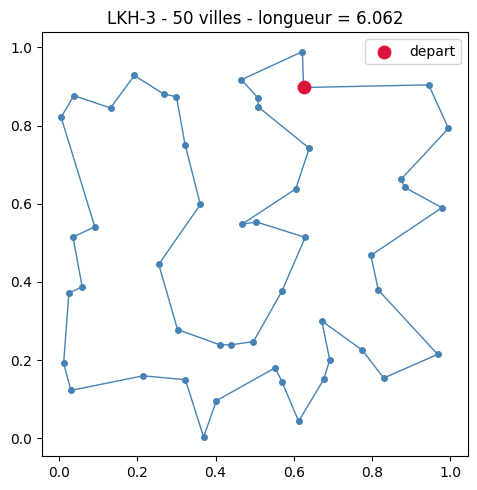

In [16]:
def plot_tour(coords: np.ndarray, tour: List[int], title: str = "") -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    t = tour + [tour[0]]
    ax.plot([coords[c, 0] for c in t], [coords[c, 1] for c in t],
            "-o", ms=4, lw=1, color="steelblue", zorder=2)
    ax.scatter(coords[tour[0], 0], coords[tour[0], 1],
               s=80, color="crimson", zorder=3, label="depart")
    ax.set_title(title or "Tournee LKH-3")
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


# Demo: 50 villes aleatoires
rng_demo   = np.random.default_rng(7)
demo_coord = rng_demo.random((50, 2))
demo_sol   = LKH3Solver(demo_coord, k=10, seed=42)
demo_tour, demo_len = demo_sol.solve(n_restarts=100)

nn_len = demo_sol._tour_length(demo_sol._nn_tour(start=0))
print(f"NN initial : {nn_len:.4f}")
print(f"LKH-3      : {demo_len:.4f}  ({(nn_len - demo_len) / nn_len * 100:.1f} % d'amelioration)")
plot_tour(demo_coord, demo_tour, title=f"LKH-3 - 50 villes - longueur = {demo_len:.3f}")


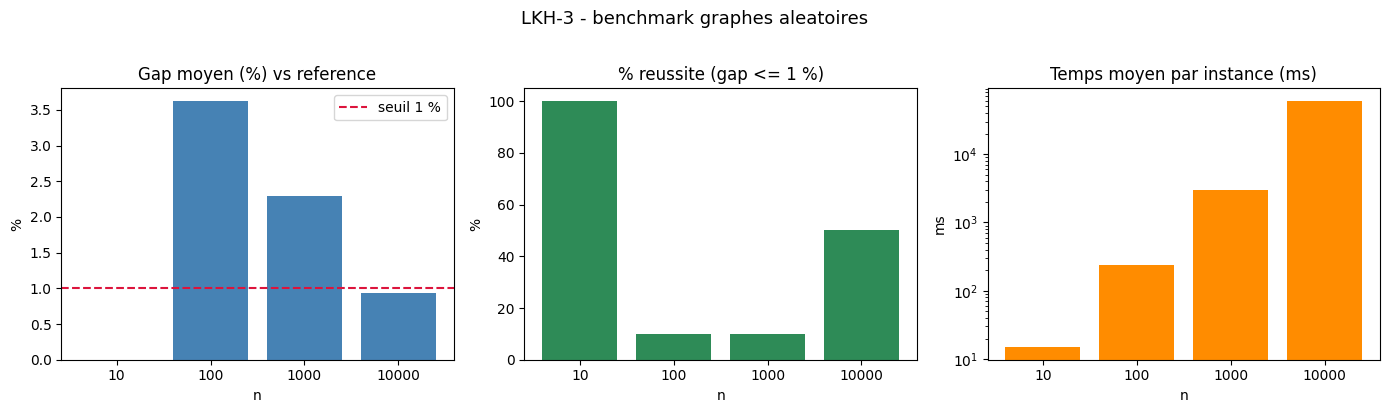


Tableau recapitulatif :


,% reussite,% non-detection,% fausse detection,Gap moyen (%),Gap max (%),Temps moyen (ms)
n,,,,,,
1,100 %,0 %,0 %,0.000,0.000,0.0 +/- 0.0
10,100 %,0 %,0 %,0.000,0.000,14.8 +/- 1.2
100,10 %,0 %,0 %,3.620,6.566,241.4 +/- 19.7
1000,10 %,0 %,0 %,2.292,5.828,3021.2 +/- 508.4
10000,50 %,0 %,25 %,0.929,2.365,60536.9 +/- 3528.7


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sizes  = [n for n in sorted(results_by_n) if n > 1]
labels = [str(n) for n in sizes]

mean_gaps  = [np.mean([r["gap"]     for r in results_by_n[n]]) for n in sizes]
success_rt = [np.mean([r["success"] for r in results_by_n[n]]) * 100 for n in sizes]
mean_times = [np.mean([r["elapsed"] for r in results_by_n[n]]) * 1_000 for n in sizes]

axes[0].bar(labels, mean_gaps, color="steelblue")
axes[0].axhline(1.0, color="crimson", ls="--", label="seuil 1 %")
axes[0].set_title("Gap moyen (%) vs reference")
axes[0].set_xlabel("n") ; axes[0].set_ylabel("%") ; axes[0].legend()

axes[1].bar(labels, success_rt, color="seagreen")
axes[1].set_ylim(0, 105)
axes[1].set_title("% reussite (gap <= 1 %)")
axes[1].set_xlabel("n") ; axes[1].set_ylabel("%")

axes[2].bar(labels, mean_times, color="darkorange")
axes[2].set_yscale("log")
axes[2].set_title("Temps moyen par instance (ms)")
axes[2].set_xlabel("n") ; axes[2].set_ylabel("ms")

plt.suptitle("LKH-3 - benchmark graphes aleatoires", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nTableau recapitulatif :")
df_random
